#**Continuación Cadenas de Markov**

## 1. Cadenas de Markov que no convergen



Una cadena periódica tiene estados que solo se pueden visitar en múltiplos de un número mayor que 1.  Por ejemplo, la siguiente matriz de transición:


<br>

$$
P = \begin{bmatrix}
0 & 1 \\
1 & 0
\end{bmatrix}
$$


<br>

- El estado 0 solo puede volver a sí mismo después de 2 pasos, igual para el estado 1.  

<br>

- Una cadena periódica **no converge** a una distribución estacionaria en pasos individuales porque los estados alternan regularmente, aunque existe una distribución estacionaria si se toman **pasos múltiplos del período**.


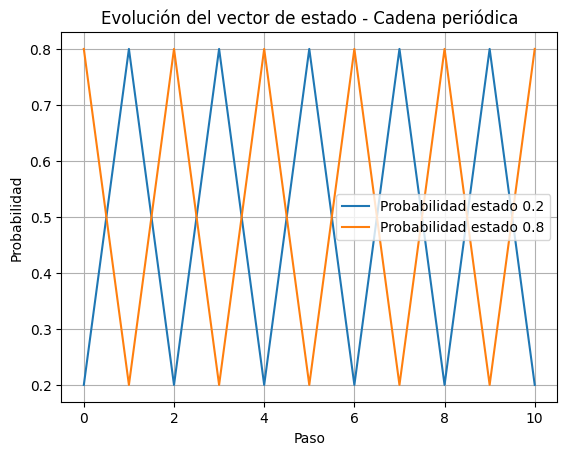

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Matriz de transición periódica
P_periodic = np.array([[0, 1],
                       [1, 0]])

# Vector inicial
p0 = np.array([0.2, 0.8])

# Evolución
n_steps = 10
p = p0
history = [p0]

for _ in range(n_steps):
    p = p @ P_periodic
    history.append(p)




history = np.array(history)

# Graficar evolución

plt.plot(history[:,0], label="Probabilidad estado 0.2")
plt.plot(history[:,1], label="Probabilidad estado 0.8")
plt.title("Evolución del vector de estado - Cadena periódica")
plt.xlabel("Paso")
plt.ylabel("Probabilidad")
plt.legend()
plt.grid(True)
plt.show()

## 2. Algunas definiciones importantes

<br>

### Distribución límite

En una cadena de Markov con matriz de transición $P$, una **distribución límite** $\lambda$ es un vector de probabilidades que describe el comportamiento a largo plazo de la cadena, si este límite existe:

<br>

$$
\lambda = \lim_{t \to \infty} \mathbf{v}_0  P^t
$$

<br>

para cualquier vector inicial $\mathbf{p}_0$. En otras palabras, cuando $t \to \infty$, la probabilidad de estar en cada estado tiende a los valores de $\pi$, independientemente del estado inicial.



<br>

<br>


### Matriz estocástica

Una **matriz estocástica** es una matriz cuadrada $P = [p_{ij}]$ que representa las probabilidades de transición de una cadena de Markov. Cumple dos propiedades:

<br>

1. Todos los elementos son no negativos:
$
p_{ij} \ge 0, \quad \forall i,j
$
2. La suma de cada fila es 1:
$
\sum_j p_{ij} = 1, \quad \forall i
$
3. P es cuadrada (mismo numero de filas que de columnas).

<br>

Esto asegura que cada fila representa una **distribución de probabilidad** sobre los estados posibles desde el estado $i$.



<br>

<br>

## 3. Trayectoria (o camino) en una cadena de Markov


Una **trayectoria** (o **camino**) de una cadena de Markov es una **secuencia de estados** visitados por la cadena a lo largo del tiempo, comenzando desde un estado inicial $v_0$.  

Se puede denotar como:

$$
(X_0, X_1, X_2, \dots, X_t)
$$

donde cada $X_k$ representa el estado en el paso $k$. Una trayectoria permite estudiar **cómo evoluciona la cadena paso a paso** y analizar propiedades como periodicidad, convergencia o comportamiento a largo plazo.


<br>

### Ejemplo

Consideremos la siguiente cadena de Markov con 3 estados denotados por (1,2,3):

$$
P =
\begin{bmatrix}
0.5 & 0.3 & 0.2 \\
0.1 & 0.6 & 0.3 \\
0.2 & 0.3 & 0.5
\end{bmatrix}
$$

y un **vector de estado inicial**:

$$
\mathbf{v}_0 = [1, 0, 0]
$$

In [ ]:
import numpy as np

# Matriz de transición
P = np.array([[0.5, 0.3, 0.2],
              [0.1, 0.6, 0.3],
              [0.2, 0.3, 0.5]])

# Vector de estado inicial
p0 = np.array([1.0, 0.0, 0.0])

# Evolución del vector de estado
n_steps = 5
p_t = [p0]

p = p0.copy()
for _ in range(n_steps):
    p = p @ P
    p_t.append(p)

p_t = np.array(p_t)
print("Evolución del vector de estado:")
print(p_t)

Evolución del vector de estado:
[[1.      0.      0.     ]
 [0.5     0.3     0.2    ]
 [0.32    0.39    0.29   ]
 [0.257   0.417   0.326  ]
 [0.2354  0.4251  0.3395 ]
 [0.22811 0.42753 0.34436]]


###Generación de trayectorias

Podemos simular 3 trayectorias posibles a partir del estado inicial:

In [ ]:
# Número de estados
n = 3

# Estado inicial
actual = 0

# Número de pasos de la trayectoria
T = 5

trayectoria = [actual]

for t in range(T):


    # Elegir siguiente estado usando la fila correspondiente
    actual = np.random.choice( n , p=P[actual] )
    # P[actual] es la distribución de probabilidad de transición desde el estado actual.
    print(P[actual])

    trayectoria.append(actual)

print("Trayectoria simulada:")
print(trayectoria)



[0.2 0.3 0.5]
[0.1 0.6 0.3]
[0.2 0.3 0.5]
[0.2 0.3 0.5]
[0.2 0.3 0.5]
Trayectoria simulada:
[0, 2, 1, 2, 2, 2]



<br>


## Verosimilitud de una trayectoria

Sea una cadena de Markov con **matriz de transición** $P$ y **vector de estado inicial** $\mathbf{v}_0$.  

Una **trayectoria** es una secuencia de estados visitados $(X_0, X_1, \dots, X_n)$

La **verosimilitud** (o probabilidad) de esta trayectoria es la probabilidad de que la cadena siga exactamente esa secuencia de estados, dadas las probabilidades iniciales y las transiciones de la matriz $P$.


<br>

## Definición matemática

$$\mathcal{L}(X_0, X_1, \dots, X_n) =  \prod_{t=0}^{n-1} P_{X_t, X_{t+1}}$$


donde  $P_{X_t, X_{t+1}}$ es la probabilidad de transición del estado $X_t$ a $X_{t+1}$ según la matriz $P$.  


<br>

#### Interpretación

1. **Probabilidad total de la secuencia:** La verosimilitud indica qué tan probable es que la cadena siga exactamente ese camino.  

<br>

3. **Comparación entre trayectorias:** Trayectorias con transiciones más probables según $P$ tendrán verosimilitudes mayores, y las menos probables tendrán verosimilitudes más pequeñas.



<br>



### **Ejemplo numérico**

Supongamos la trayectoria: $(0, 1, 2, 2, 1, 2)$ en nuestro problema anterior de trayectorias, para el proceso de markov con vector inicial $\mathbf{p}_0 = [1,0,0]$ con la matriz de transición

$$P =
\begin{bmatrix}
0.5 & 0.3 & 0.2 \\
0.1 & 0.6 & 0.3 \\
0.2 & 0.3 & 0.5
\end{bmatrix}$$

<br>

La verosimilitud se calcula como:

$$\begin{aligned}
\mathcal{L} &=   P_{0,1} \cdot P_{1,2} \cdot P_{2,2} \cdot P_{2,1} \cdot P_{1,2} \\
&= 1 \cdot 0.3 \cdot 0.3 \cdot 0.5 \cdot 0.3 \cdot 0.3 \\
&= 0.00324
\end{aligned}$$

<br>

- Esto significa que hay aproximadamente un **0.3% de probabilidad** de que la cadena siga exactamente esa secuencia de estados.

- Si alguna transición tiene probabilidad 0, la verosimilitud sería 0, indicando que esa trayectoria es **imposible** según $P$.


 <br>

NOTA:  **verosimilitud de la trayectoria** nos permite cuantificar la **probabilidad exacta de un camino específico** que sigue la cadena de Markov a partir del estado inicial y de la matriz de transición.

In [ ]:
# Matriz de transición (3 estados)
P = np.array([
    [0.2, 0.5, 0.3],   # desde estado 0
    [0.1, 0.6, 0.3],   # desde estado 1
    [0.4, 0.2, 0.4]    # desde estado 2
])

# Estado inicial (supongamos que es fijo)
estado_inicial = 0

# Número de estados
n = 3

# Simular una trayectoria de longitud 4
T = 4
trayectoria = [estado_inicial]

actual = estado_inicial
for t in range(T):
    actual = np.random.choice(n, p=P[actual])
    trayectoria.append(actual)

print("Trayectoria simulada:")
print(trayectoria)

# -----------------------------------------------------------
# Cálculo de la probabilidad de la trayectoria:
#   P(X0 = x0) * Π P(x_t -> x_{t+1})
# Si el estado inicial es fijo, P(X0=x0)=1
# -----------------------------------------------------------

prob = 1.0
for t in range(len(trayectoria) - 1):
    i = trayectoria[t]
    j = trayectoria[t+1]
    prob *= P[i, j]

print("\nProbabilidad de la trayectoria:")
print("Probabilidad de la trayectoria encontrada: ", prob * 100 ,"%")

Trayectoria simulada:
[0, 1, 2, 2, 2]

Probabilidad de la trayectoria:
Probabilidad de la trayectoria encontrada:  2.4 %


##Pregunta:  **¿Como encontrar la trayectoria mas probable?**

**R/:** Algoritmo de Viterbi: Tema opcional y no sera evaluado.

<br>

<br>

<br>

-----------------------------------------

## **Idea del algoritmo (TEMA OPCIONAL)**
<br>

Definir $\delta_t(j)$ como la probabilidad de la trayectoria más probable que termina en el estado $j$ en el paso $t$.

<br>

1. **Inicialización**

$$
\delta_0(j) = p_0(j)
$$


<br>

2. **Recurrencia**

Para cada paso $t = 1, \dots, T$ y cada estado $j$:

$$
\delta_t(j) = \max_i \big[ \delta_{t-1}(i) \cdot P_{i,j} \big]
$$

Aquí, $\delta_{t-1}(i)$ es la probabilidad máxima hasta el paso $t-1$  terminando en el estado $i$. Multiplicamos por $P_{i,j}$ porque esa es la probabilidad de ir de $i$ a $j$.

<br>

3. **Guardar punteros**

Definir los punteros

$$
\psi_t(j) = \arg\max_i \big[ \delta_{t-1}(i) \cdot P_{i,j} \big]
$$

que indican el estado $i$ que dio el máximo.


<br>


4. **Backtracking**

El último estado de la trayectoria más probable es:

$$
x_T^* = \arg\max_j \delta_T(j)
$$

Y reconstruimos la trayectoria hacia atrás:

$$
x_{t-1}^* = \psi_t(x_t^*), \quad t = T, T-1, \dots, 1
$$



<br>

## Resumen en palabras sencillas

- **Paso 0:** Inicializas la probabilidad máxima de cada estado con la probabilidad inicial.

- **Paso t:** Para cada estado, eliges el estado previo que te da la mayor probabilidad acumulada multiplicada por la transición.

- **Backtracking:** Una vez llegas al último paso, reconstruyes la trayectoria más probable siguiendo los punteros.


<br>

**Ventaja de este algoritmo:** No necesitas revisar todas las trayectorias posibles (que serían exponenciales); solo multiplicas y comparas paso a paso.



##**Ejemplo**  

<br>

## 1. Definición de la cadena

- Estados: $S = \{0, 1\}$  
- Matriz de transición:

$$
P = \begin{bmatrix}
0.6 & 0.4 \\
0.3 & 0.7
\end{bmatrix}
$$

- Vector inicial:

$$
p_0 = [1, 0]  \quad (\text{comenzamos seguro en el estado 0})
$$

- Número de pasos: $T = 2$  

<br>

## 2. Paso 0: Inicialización

La **probabilidad máxima** de cada estado en el paso 0 es simplemente la inicial:

$$
\delta_0(0) = 1, \quad \delta_0(1) = 0
$$

Punteros iniciales (no hay paso anterior):

$$
\psi_0(0) = -, \quad \psi_0(1) = -
$$

<br>

## 3. Paso 1: calcular $$\delta_1(j)$$

$$
\delta_1(j) = \max_i [\delta_0(i)\cdot P_{i,j}]
$$

- Para $j=0$:

$$
\delta_1(0) = \max[1\cdot 0.6, 0\cdot 0.3] = 0.6
$$

- Para $j=1$:

$$
\delta_1(1) = \max[1\cdot 0.4, 0\cdot 0.7] = 0.4
$$

**Punteros:**

$$
\psi_1(0) = 0, \quad \psi_1(1) = 0
$$

<br>

## 4. Paso 2: calcular $$\delta_2(j)$$

$$
\delta_2(j) = \max_i [\delta_1(i)\cdot P_{i,j}]
$$

- Para $j=0$:

$$
\delta_2(0) = \max[0.6\cdot 0.6, 0.4\cdot 0.3] = \max[0.36, 0.12] = 0.36
$$

- Para $j=1$:

$$
\delta_2(1) = \max[0.6\cdot 0.4, 0.4\cdot 0.7] = \max[0.24, 0.28] = 0.28
$$

**Punteros:**

$$
\psi_2(0) = 0 \quad (\text{viene de estado 0})
$$

$$
\psi_2(1) = 1 \quad (\text{viene de estado 1})
$$


<br>

## 5. Backtracking: reconstruir la trayectoria más probable

1. **Elegimos el último estado** usando $\delta$:

$$
x_2^* = \arg\max_j \delta_2(j) = 0
$$


Nota: el **último estado no lo da el puntero**, sino que se elige mirando cuál $$\delta_2(j)$$ es mayor.


2. **Retrocedemos usando punteros**:

$$
x_1^* = \psi_2(x_2^*) = \psi_2(0) = 0
$$

$$
x_0^* = \psi_1(x_1^*) = \psi_1(0) = 0
$$




<br>

## 6. Resultado final

- **Trayectoria más probable:**

$$
X^* = (0, 0, 0)
$$

- **Verosimilitud:**

$$
\mathcal{L}(X^*) = p_0(0)\cdot P_{0,0}\cdot P_{0,0} = 1 \cdot 0.6 \cdot 0.6 = 0.36 = 36\%
$$


